[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/penny/gavd3/06_capstone_health_condition_classifiers.ipynb)

# 06. Capstone health-condition classifiers

Freeze the S-JEPA target encoder, fit Random Forest probes, reproduce the exp5 comparison lane, and stop leakage from hiding in the score.

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

**Run it:** locally, use `uv sync` then `uv run jupyter lab` from this folder. In Colab, use the badge and run the setup cell. Restart the kernel after changing `penny/gavd3/.env`.

**Keep the walk visible:** notebook 01 opens the source video, and notebook 02 shows frame, bbox, and skeleton alignment. Revisit those views whenever a latent or classifier result looks surprising.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "penny" / "gavd3"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD3_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD3_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "penny" / "gavd3" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD3_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD3_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: /Users/pmui/dev/alexpose
GAVD CSVs: /Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4/data-gavd
YouTube cache: /Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4/youtube
artifacts: /Users/pmui/dev/alexpose/penny/gavd3/cache/artifacts/real


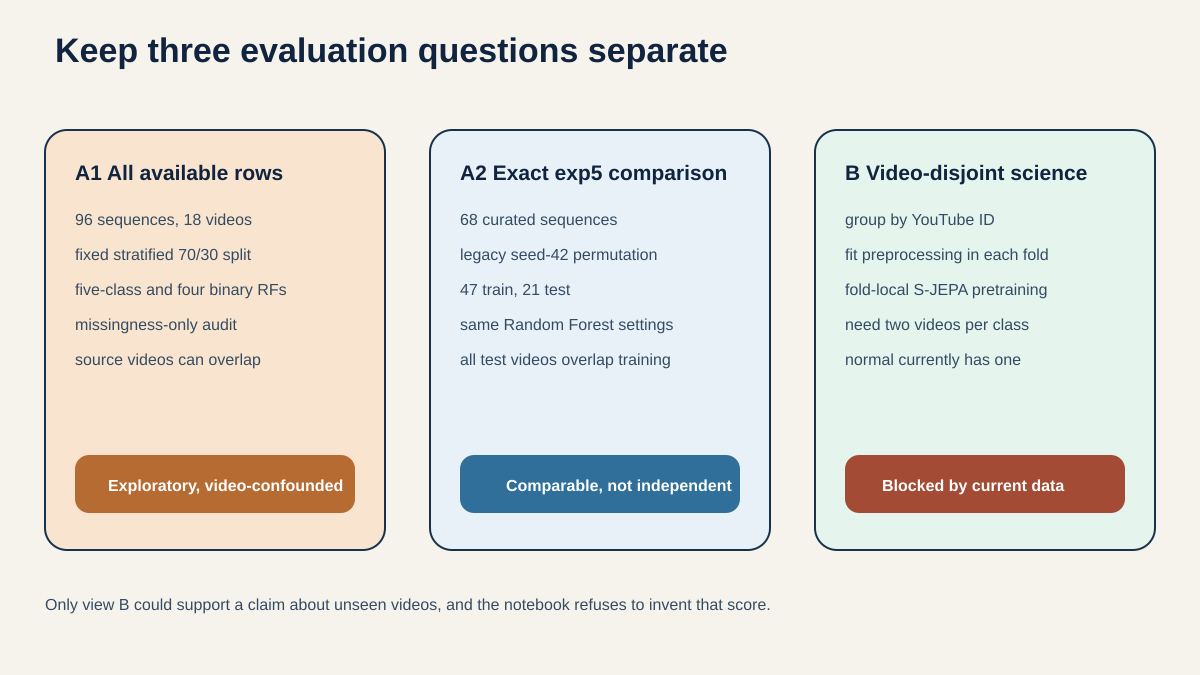

In [2]:
show_tutorial_svg("08_evaluation_protocol.svg")


In [3]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 31, 32]
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]


In [4]:
CONDITIONS = ["normal", "parkinsons", "stroke", "cerebralpalsy", "myopathic"]


In [5]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "cerebralpalsy", "myopathic"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


In [6]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    '''Fill only short internal gaps and preserve the original validity mask.

    Long gaps and sequence ends are never extrapolated. Their coordinates remain
    missing until center_and_scale converts them to an explicit zero sentinel.
    They can never become S-JEPA prediction targets.
    '''
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(
    sequence,
    frames=64,
    visibility_threshold=0.45,
    max_gap=4,
):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [7]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


def sjepa_cross_entropy(
    predicted,
    targets,
    center,
    predictor_temperature=0.10,
    target_temperature=0.06,
):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature,
        dim=-1,
    ).detach()
    prediction_log_prob = torch.log_softmax(
        predicted / predictor_temperature,
        dim=-1,
    )
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0


LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12),
    (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def geometric_view(
    x,
    max_degrees=8.0,
    translate=0.03,
    flip_probability=0.0,
):
    """Apply one sequence-wide transform per sample.

    Rotation is around the relative vertical y axis, so x and z are mixed.
    Flip defaults to off because laterality can matter for stroke. If enabled,
    coordinates are reflected and every left-right landmark pair is swapped.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (
        torch.rand(batch, device=x.device) * 2.0 - 1.0
    ) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x = view[..., 0].clone()
    original_z = view[..., 2].clone()
    rotated_x = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    rotated_z = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., 0] = rotated_x
    view[..., 2] = rotated_z
    offsets = (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    view[..., :2] += offsets
    if flip_probability > 0:
        flip = torch.rand(batch, device=x.device) < flip_probability
        for batch_index in torch.where(flip)[0].tolist():
            view[batch_index, ..., 0] *= -1.0
            original = view[batch_index].clone()
            original_present = present[batch_index].clone()
            for left, right in LEFT_RIGHT_PAIRS:
                view[batch_index, :, left] = original[:, right]
                view[batch_index, :, right] = original[:, left]
                present[batch_index, :, left] = original_present[:, right]
                present[batch_index, :, right] = original_present[:, left]
    view = view.masked_fill(~present[..., None], 0.0)
    return view


In [8]:
def pose_records_from_cache(pose_dir=POSE_DIR, conditions=CONDITIONS):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            required = {
                "sequence", "sequence_id", "video_id", "condition",
                "frame_numbers", "crop_bounds", "fps", "source_csv",
                "source_video", "pose_model", "pose_model_sha256",
                "extraction_version",
            }
            missing = required.difference(data.files)
            if missing:
                raise ValueError(
                    f"Stale pose cache {path} is missing {sorted(missing)}. "
                    "Re-extract it with notebook 02."
                )
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            stored_condition = str(data["condition"].item())
            if stored_condition != condition:
                raise ValueError(
                    f"Pose condition {stored_condition} does not match folder {condition}"
                )
            if len(data["frame_numbers"]) != len(sequence):
                raise ValueError(f"Frame and pose lengths differ in {path}")
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "source_video": str(data["source_video"].item()),
                "fps": float(data["fps"].item()),
                "extraction_version": str(data["extraction_version"].item()),
                "pose_model_sha256": str(data["pose_model_sha256"].item()),
                "sequence": sequence,
                "path": str(path),
            })
    return records


def load_records_for_mode(conditions=CONDITIONS, smoke_per_condition=10, frames=64):
    if MODE == "smoke":
        records = synthetic_corpus(
            conditions=conditions,
            n_per_condition=smoke_per_condition,
            frames=frames,
        )
        print(f"Explicit smoke corpus: {len(records)} synthetic sequences")
        return records
    records = pose_records_from_cache(conditions=conditions)
    counts = pd.Series([r["condition"] for r in records]).value_counts()
    missing = [condition for condition in conditions if counts.get(condition, 0) == 0]
    if missing:
        raise FileNotFoundError(
            f"Real mode requires cached pose sequences for {missing}. "
            "Run notebook 02 first."
        )
    print(f"Real pose corpus: {len(records)} sequences")
    return records


In [9]:
EXP5_ORDER = [
    "cljvvsucg00043n6l4evgn7q4", "cljr5jk0h000n3n6la34mkdfz",
    "cljo8eumx00683n6le2s7myd4", "cljr5fc5d000b3n6lkvc71zyl",
    "cljr5iki0000j3n6lwi8z5nh6", "cljo8cyv500603n6lyl148tmg",
    "cljo8g74m006g3n6l6kuxy9cf", "cljo8hcfv006k3n6lgrx0fcpx",
    "cljo8fdke006c3n6lr8bzjjgi", "cljo8c0sw005w3n6l9ulr2eg2",
    "cljo8e32t00643n6l37ncjeic", "cljr5hwxc000f3n6lof5w9tyt",
    "cljarhldg00d13n6l7utw0lqn", "cljo83yl800513n6lfglf5jn8",
    "cljawdoej000d3n6ll5ysj34f", "cljarmcm700dh3n6lxw24hxgx",
    "cljaxabfg003a3n6l95mrlcry", "cljarj6rf00d53n6ljtivf4q7",
    "cljarlbch00dd3n6l9jaubrxq", "cljarp08600dt3n6lxa7sysiv",
    "cljarpts600dx3n6l98zqf6yn", "cljaroguw00dp3n6lhfddiadu",
    "cljargosy00cx3n6lm6atozrz", "cljarn9oy00dl3n6l8pg9exfg",
    "cljarqtuz00e13n6lrnox6mfs", "cljaxbq22003i3n6lmzka93uq",
    "cljarkax200d93n6lukx52g1t", "cljax9d2p00363n6lx043s1m7",
    "cljaxb5y2003e3n6lj1j9qvav", "cljo84jju00553n6lmgm4dqtb",
    "cljawd01m00093n6l4kx9020l", "cljawb5nf00043n6l38chxsod",
    "cljnz7jnj000w3n6lku3pfvtm", "cljnz6vg1000s3n6lxxknbe72",
    "cljnz3l34000c3n6ldapq560j", "cljnz5sb1000o3n6lntosswwz",
    "cljan9b4p00043n6ligceanyp", "cljanb45y00083n6lmh1qhydd",
    "cljnyzwbo00043n6lugyldlhu", "cljnz4y5a000k3n6lkv4b1rjn",
    "cljnz4e8u000g3n6l1luikppo", "cljo340cm002a3n6low42ugvh",
    "cljo32xnz00223n6lvxzyif3y", "cljo33m8400263n6l4xxsl6ku",
    "cljo2y1f7001e3n6lt1wgacw6", "cljo3b2dy002l3n6l270vpzp8",
    "cljo2yqzp001i3n6lg75p7wtq", "cljo39ok9002h3n6ldr0w5sey",
    "cljo30lnz001q3n6lopfty7q5", "cljo2wwu7001a3n6ljmqm39l6",
    "cljo2zn41001m3n6lhbvww48i", "cljo32ik2001y3n6lmmnu0sgo",
    "cljo32213001u3n6lel97up5f", "cljar9bqo00c43n6l2u5zmlru",
    "cljarbn1y00cg3n6l1u4i0d5l", "cljardvzg00cs3n6loetskba6",
    "cljas71p600fv3n6lk1rzl7y5", "cljas134500f73n6lkfbjfayp",
    "cljarcfa700ck3n6lfww83ig1", "cljar9t8o00c83n6ltculhoct",
    "cljas1yfs00fb3n6lna38ui6i", "cljarar9t00cc3n6lqhi9udoc",
    "cljas5esv00fn3n6lewd5xqdl", "cljas4dqj00fj3n6ldw6wiwpy",
    "cljar878f00c03n6ly2v2ay88", "cljas04fw00f33n6lm5cvx9g6",
    "cljas2sou00ff3n6lasppj8h2", "cljarcy3g00co3n6lzsn1x034",
]


def exp5_exact_split(order, train_portion=0.70):
    """Reproduce the original notebook's legacy NumPy permutation."""
    np.random.seed(42)
    permutation = np.random.permutation(len(order))
    split_index = int(train_portion * len(order))
    train_ids = [order[index] for index in permutation[:split_index]]
    test_ids = [order[index] for index in permutation[split_index:]]
    return train_ids, test_ids


assert len(EXP5_ORDER) == 68


## The capstone question

Does a frozen encoder pretrained only on normal gait produce sequence embeddings that help separate normal, Parkinson's, stroke, cerebral palsy, and myopathic gait?

The classifier sees one vector per GAVD sequence. It never sees individual windows as independent rows. This prevents a train-test split from putting near-duplicate windows from one sequence on both sides.


## Load the target encoder and every condition

Only the EMA target encoder is used downstream, matching the S-JEPA paper. The view encoder and predictor remain in the checkpoint for auditability but do not create classifier features.


In [10]:
checkpoint_path = ARTIFACT_DIR / "sjepa_normal.pt"
if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Missing {checkpoint_path}. Run notebook 04 in {MODE} mode."
    )
checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False,
)
if checkpoint["mode"] != MODE:
    raise ValueError("Checkpoint mode does not match this notebook")
if checkpoint["mask_keypoints"] != MASK_KEYPOINTS:
    raise ValueError("Checkpoint used a different mask keypoint set")
config = checkpoint["config"]
model = SJEPAGait(**config)
model.load_state_dict(checkpoint["model_state"])
model.eval()
FRAMES = config["frames"]

records = load_records_for_mode(
    conditions=CONDITIONS,
    smoke_per_condition=10,
    frames=FRAMES,
)
prepared = [
    prepare_sequence(record["sequence"], frames=FRAMES)
    for record in records
]
all_xyz = np.stack([item[0] for item in prepared])
all_valid = np.stack([item[1] for item in prepared])
sequence_ids = np.asarray([record["sequence_id"] for record in records])
video_ids = np.asarray([record["video_id"] for record in records])
labels = np.asarray([record["condition"] for record in records])
if len(set(sequence_ids.tolist())) != len(sequence_ids):
    raise ValueError("Cached pose sequence IDs must be unique")
if MODE == "real":
    expected_sequences = {
        "cerebralpalsy": 16,
        "myopathic": 47,
        "normal": 12,
        "parkinsons": 9,
        "stroke": 12,
    }
    expected_videos = {
        "cerebralpalsy": 2,
        "myopathic": 10,
        "normal": 1,
        "parkinsons": 2,
        "stroke": 3,
    }
    actual_sequences = pd.Series(labels).value_counts().to_dict()
    actual_videos = (
        pd.DataFrame({"condition": labels, "video_id": video_ids})
        .groupby("condition")["video_id"]
        .nunique()
        .to_dict()
    )
    if actual_sequences != expected_sequences:
        raise ValueError(
            f"Real capstone requires all 96 poses: {actual_sequences}"
        )
    if actual_videos != expected_videos:
        raise ValueError(
            f"Unexpected 18-video census: {actual_videos}"
        )
min_coverage = float(os.getenv("GAVD_MIN_NEURO_COVERAGE", "0.50"))
coverage_report = pd.DataFrame({
    "condition": labels,
    "sequence_id": sequence_ids,
    "video_id": video_ids,
    "neurologic_observed_fraction": all_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2)),
})
display(coverage_report.groupby("condition")["neurologic_observed_fraction"].agg(["min", "mean"]))
if (coverage_report["neurologic_observed_fraction"] < min_coverage).any():
    raise ValueError("At least one sequence fails the neurologic coverage threshold")
coverage_report.to_csv(
    ARTIFACT_DIR / "classifier_pose_coverage.csv", index=False
)
display(pd.crosstab(labels, columns="sequences"))


Real pose corpus: 96 sequences


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_93948/3075790523.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_93948/3075790523.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


,min,mean
condition,,
cerebralpalsy,0.776563,0.984766
myopathic,0.939063,0.994016
normal,0.951562,0.991667
parkinsons,0.812500,0.965278
stroke,0.578125,0.941536


col_0,sequences
row_0,
cerebralpalsy,16
myopathic,47
normal,12
parkinsons,9
stroke,12


## Audit detector missingness as a possible shortcut

Invalid landmarks remain zero sentinels inside the encoders so the timeline and tensor shape stay fixed. Validity-masked pooling prevents those zero tokens from contributing directly to the pooled statistics, but neighboring Transformer tokens can still encode the detector-failure pattern. We therefore save a missingness signature for every sequence and later fit the same Random Forest using only that signature.

A strong missingness-only score would mean the pose detector, source video, crop quality, or occlusion pattern can predict labels. It would not prove that the latent classifier uses the shortcut, but it would make a gait-only interpretation unsafe.


In [11]:
missingness_features = np.concatenate(
    [
        all_valid.mean(axis=1),
        all_valid.mean(axis=2),
    ],
    axis=1,
).astype(np.float32)
missingness_columns = [
    *[f"joint_valid_fraction_{joint:02d}" for joint in range(33)],
    *[f"frame_valid_fraction_{frame:02d}" for frame in range(FRAMES)],
]
missingness_table = pd.DataFrame(
    missingness_features, columns=missingness_columns
)
missingness_table.insert(0, "video_id", video_ids)
missingness_table.insert(0, "sequence_id", sequence_ids)
missingness_table.insert(0, "condition", labels)
missingness_table.to_csv(
    ARTIFACT_DIR / "pose_missingness_features.csv", index=False
)
display(
    coverage_report.groupby("condition")[
        "neurologic_observed_fraction"
    ].agg(["min", "mean", "max"])
)


,min,mean,max
condition,,,
cerebralpalsy,0.776563,0.984766,1.0
myopathic,0.939063,0.994016,1.0
normal,0.951562,0.991667,1.0
parkinsons,0.812500,0.965278,1.0
stroke,0.578125,0.941536,1.0


## Freeze and pool

The pooling contract is the same as notebook 05: validity-masked global mean and standard deviation, followed by validity-masked mean and standard deviation over the ten neurologic landmarks. A patch contributes only when all four source frames are valid for that joint. It is documented because the S-JEPA paper does not specify exact downstream pooling.


In [12]:
def masked_mean_std(tokens, mask):
    weights = torch.as_tensor(
        mask, dtype=tokens.dtype, device=tokens.device
    ).unsqueeze(-1)
    denominator = weights.sum(dim=1).clamp_min(1.0)
    mean = (tokens * weights).sum(dim=1) / denominator
    variance = (
        (tokens - mean[:, None, :]).square() * weights
    ).sum(dim=1) / denominator
    return mean, variance.clamp_min(0.0).sqrt()


@torch.no_grad()
def pooled_embeddings(model, arrays, validity, batch_size=8):
    vectors = []
    segments = model.target_encoder.segments
    segment_length = model.target_encoder.segment_length
    dimension = model.target_encoder.embed_dim
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(
            arrays[start:start + batch_size],
            dtype=torch.float32,
        )
        tokens = model.target_encoder(batch).reshape(
            len(batch), segments, 33, dimension
        )
        valid_patch = np.asarray(
            validity[start:start + batch_size], dtype=bool
        ).reshape(
            len(batch), segments, segment_length, 33
        ).all(axis=2)
        global_tokens = tokens.reshape(len(batch), -1, dimension)
        neuro_tokens = tokens[:, :, MASK_KEYPOINTS].reshape(
            len(batch), -1, dimension
        )
        global_mean, global_std = masked_mean_std(
            global_tokens, valid_patch.reshape(len(batch), -1)
        )
        neuro_mean, neuro_std = masked_mean_std(
            neuro_tokens,
            valid_patch[:, :, MASK_KEYPOINTS].reshape(len(batch), -1),
        )
        vectors.append(torch.cat([
            global_mean,
            global_std,
            neuro_mean,
            neuro_std,
        ], dim=1).cpu())
    return torch.cat(vectors).numpy()


embeddings = pooled_embeddings(model, all_xyz, all_valid)
assert embeddings.shape[0] == len(sequence_ids)
assert np.isfinite(embeddings).all()
feature_columns = [
    f"latent_{index:04d}" for index in range(embeddings.shape[1])
]
embedding_table = pd.DataFrame(embeddings, columns=feature_columns)
embedding_table.insert(0, "video_id", video_ids)
embedding_table.insert(0, "sequence_id", sequence_ids)
embedding_table.insert(0, "condition", labels)
embedding_table.insert(0, "mode", MODE)
embedding_table.insert(
    0, "checkpoint_fingerprint", checkpoint["dataset_fingerprint"]
)
embedding_path = ARTIFACT_DIR / "sequence_embeddings.parquet"
embedding_table.to_parquet(embedding_path, index=False)
print("embedding matrix:", embeddings.shape)
print("saved:", embedding_path)


embedding matrix: (96, 384)
saved: /Users/pmui/dev/alexpose/penny/gavd3/cache/artifacts/real/sequence_embeddings.parquet


## Match the exp5 Random Forest

exp5 used StandardScaler, 100 trees, maximum depth 5, sqrt feature sampling, bootstrap, balanced class weights, and random state 42.

Its split was not stratified. It used the legacy global NumPy random state and permuted the native 68-item feature order. Using default_rng produces a different test set.


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

CLASS_ORDER = [
    "cerebralpalsy", "myopathic", "normal", "parkinsons", "stroke"
]


def make_rf():
    return Pipeline([
        ("scale", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            max_features="sqrt",
            bootstrap=True,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ])


def score_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
    }


## Lane A1: all available sequences

This exploratory lane uses every cached sequence, which is 96 rows in the real corpus. It makes a fixed, stratified 70/30 sequence split. It is useful for exercising all five folders and all four one-versus-normal probes, but it is still video-confounded because several sequences share a source upload.


In [14]:
from sklearn.model_selection import train_test_split

all_index = np.arange(len(labels))
all_train_index, all_test_index = train_test_split(
    all_index,
    train_size=0.70,
    random_state=42,
    stratify=labels,
)
all_train_ids = sequence_ids[all_train_index].tolist()
all_test_ids = sequence_ids[all_test_index].tolist()
all_split_name = (
    "all_96_stratified_video_confounded"
    if MODE == "real"
    else "smoke_all_stratified"
)
all_sequence_model = make_rf()
all_sequence_model.fit(
    embeddings[all_train_index], labels[all_train_index]
)
all_sequence_prediction = all_sequence_model.predict(
    embeddings[all_test_index]
)
all_sequence_metrics = score_predictions(
    labels[all_test_index], all_sequence_prediction
)
all_sequence_report = pd.DataFrame(classification_report(
    labels[all_test_index],
    all_sequence_prediction,
    labels=CLASS_ORDER,
    zero_division=0,
    output_dict=True,
)).T
all_shared_videos = sorted(
    set(video_ids[all_train_index]) & set(video_ids[all_test_index])
)
print(all_split_name, all_sequence_metrics)
print("shared train/test source videos:", all_shared_videos)
display(all_sequence_report)

all_missingness_model = make_rf()
all_missingness_model.fit(
    missingness_features[all_train_index], labels[all_train_index]
)
all_missingness_prediction = all_missingness_model.predict(
    missingness_features[all_test_index]
)
all_missingness_metrics = score_predictions(
    labels[all_test_index], all_missingness_prediction
)
print("missingness-only audit:", all_missingness_metrics)


all_96_stratified_video_confounded {'accuracy': 0.6206896551724138, 'balanced_accuracy': 0.6242857142857143, 'macro_f1': 0.5936507936507935}
shared train/test source videos: [np.str_('05oyBOE_0UE'), np.str_('3KnFt8bH3tE'), np.str_('5gpoegYv1hs'), np.str_('5qM6wxZ_dNs'), np.str_('7Ft1bUTzxkM'), np.str_('8NlJgIySMG0'), np.str_('8PPLTf0fZsY'), np.str_('8mTHlAIdea0'), np.str_('9qg-3smwLcs'), np.str_('B5hrxKe2nP8'), np.str_('DlPDuHBAP7A'), np.str_('HDkWDe6FZDg'), np.str_('R8LRCiTvUz8'), np.str_('_Wn9oYGpRdM'), np.str_('jzJIpY6vRLo'), np.str_('wRntYsztIEY')]


,precision,recall,f1-score,support
cerebralpalsy,0.571429,0.800000,0.666667,5.00000
myopathic,0.800000,0.571429,0.666667,14.00000
normal,1.000000,0.750000,0.857143,4.00000
parkinsons,0.333333,0.666667,0.444444,3.00000
stroke,0.333333,0.333333,0.333333,3.00000
accuracy,0.620690,0.620690,0.620690,0.62069
macro avg,0.607619,0.624286,0.593651,29.00000
weighted avg,0.691626,0.620690,0.635468,29.00000


missingness-only audit: {'accuracy': 0.4482758620689655, 'balanced_accuracy': 0.46571428571428575, 'macro_f1': 0.4288888888888889}


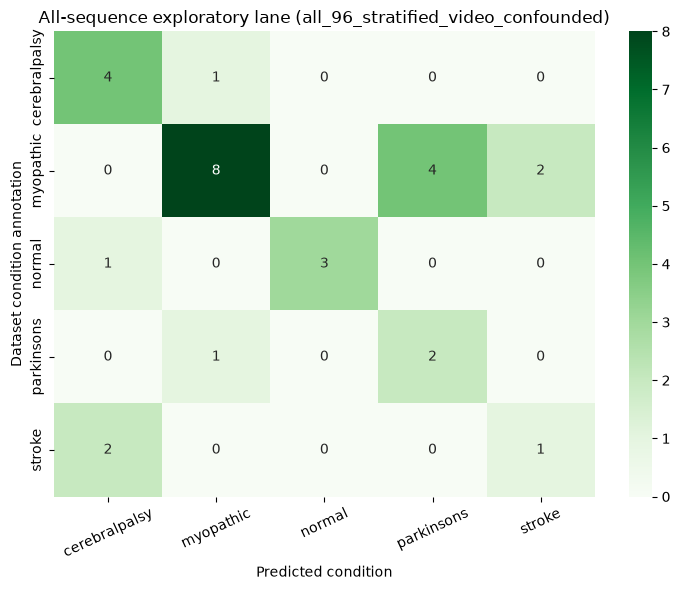

,sequence_id,video_id,true_condition,predicted_condition
4,cljr5wgkf001w3n6lwp1w3wlu,8PPLTf0fZsY,myopathic,parkinsons
5,cljanb45y00083n6lmh1qhydd,B5hrxKe2nP8,parkinsons,myopathic
8,cljo8hcfv006k3n6lgrx0fcpx,5gpoegYv1hs,stroke,cerebralpalsy
9,cljas4dqj00fj3n6ldw6wiwpy,DlPDuHBAP7A,cerebralpalsy,myopathic
12,cljr5unji001o3n6lapqpzkio,8PPLTf0fZsY,myopathic,parkinsons
17,cljawb5nf00043n6l38chxsod,HDkWDe6FZDg,myopathic,parkinsons
20,cljaxabfg003a3n6l95mrlcry,jzJIpY6vRLo,myopathic,stroke
21,cljo2zn41001m3n6lhbvww48i,3KnFt8bH3tE,normal,cerebralpalsy
22,cljo84jju00553n6lmgm4dqtb,05oyBOE_0UE,myopathic,stroke
23,cljr5nnwf000w3n6l8byrugrq,8NlJgIySMG0,myopathic,parkinsons


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

all_sequence_confusion = confusion_matrix(
    labels[all_test_index],
    all_sequence_prediction,
    labels=CLASS_ORDER,
)
all_figure, all_axis = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    all_sequence_confusion,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=all_axis,
)
all_axis.set_title(f"All-sequence exploratory lane ({all_split_name})")
all_axis.set_xlabel("Predicted condition")
all_axis.set_ylabel("Dataset condition annotation")
all_axis.tick_params(axis="x", labelrotation=25)
all_figure.tight_layout()
all_figure.savefig(
    ARTIFACT_DIR / "all_sequences_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
all_error_table = pd.DataFrame({
    "sequence_id": sequence_ids[all_test_index],
    "video_id": video_ids[all_test_index],
    "true_condition": labels[all_test_index],
    "predicted_condition": all_sequence_prediction,
})
all_error_table = all_error_table[
    all_error_table["true_condition"]
    != all_error_table["predicted_condition"]
]
display(all_error_table)


## Lane A2: exact exp5-compatible split

This second lane deliberately selects the 68 sequence IDs used by exp5 so the split and score can be compared. The other 28 sequences remain in the all-sequence lane above. Real mode refuses to continue unless all 96 cached sequences and every one of the 68 exp5 IDs are present. Smoke mode uses a clearly labelled stratified demonstration because synthetic IDs cannot reproduce exp5.


In [16]:
id_to_index = {
    sequence_id: index
    for index, sequence_id in enumerate(sequence_ids)
}
if MODE == "real":
    missing = [item for item in EXP5_ORDER if item not in id_to_index]
    if missing:
        raise FileNotFoundError(
            f"Missing {len(missing)} exp5 pose sequences. "
            "Extract the full curated set in notebook 02."
        )
    train_ids, test_ids = exp5_exact_split(EXP5_ORDER)
    train_index = np.asarray([id_to_index[item] for item in train_ids])
    test_index = np.asarray([id_to_index[item] for item in test_ids])
    split_name = "exp5_exact_video_confounded"
    assert len(train_index) == 47 and len(test_index) == 21
else:
    from sklearn.model_selection import train_test_split
    all_index = np.arange(len(labels))
    train_index, test_index = train_test_split(
        all_index,
        train_size=0.70,
        random_state=42,
        stratify=labels,
    )
    train_ids = sequence_ids[train_index].tolist()
    test_ids = sequence_ids[test_index].tolist()
    split_name = "smoke_stratified_not_exp5"

five_class_model = make_rf()
five_class_model.fit(embeddings[train_index], labels[train_index])
five_class_prediction = five_class_model.predict(embeddings[test_index])
five_class_metrics = score_predictions(
    labels[test_index], five_class_prediction
)
exp5_missingness_model = make_rf()
exp5_missingness_model.fit(
    missingness_features[train_index], labels[train_index]
)
exp5_missingness_prediction = exp5_missingness_model.predict(
    missingness_features[test_index]
)
exp5_missingness_metrics = score_predictions(
    labels[test_index], exp5_missingness_prediction
)
print(split_name, five_class_metrics)
print("missingness-only audit:", exp5_missingness_metrics)
five_class_report = pd.DataFrame(classification_report(
    labels[test_index],
    five_class_prediction,
    labels=CLASS_ORDER,
    zero_division=0,
    output_dict=True,
)).T
display(five_class_report)


exp5_exact_video_confounded {'accuracy': 0.6190476190476191, 'balanced_accuracy': 0.5961904761904762, 'macro_f1': 0.6133333333333334}
missingness-only audit: {'accuracy': 0.3333333333333333, 'balanced_accuracy': 0.3638095238095238, 'macro_f1': 0.33606060606060606}


,precision,recall,f1-score,support
cerebralpalsy,0.600000,0.600000,0.600000,5.000000
myopathic,0.625000,0.714286,0.666667,7.000000
normal,0.666667,0.666667,0.666667,3.000000
parkinsons,1.000000,0.666667,0.800000,3.000000
stroke,0.333333,0.333333,0.333333,3.000000
accuracy,0.619048,0.619048,0.619048,0.619048
macro avg,0.645000,0.596190,0.613333,21.000000
weighted avg,0.636905,0.619048,0.622222,21.000000


## Expose video overlap and pretraining overlap

A sequence-level split is not independent when train and test rows come from the same source upload. A normal test sequence also overlaps self-supervised pretraining when the encoder was pretrained on all normal sequences.


In [17]:
pretraining_ids = set(checkpoint["sequence_ids"])


def leakage_row(name, fit_index, held_out_index):
    fit_videos = set(video_ids[fit_index])
    held_out_videos = set(video_ids[held_out_index])
    overlap = sorted(fit_videos & held_out_videos)
    ssl_overlap = sorted(
        set(sequence_ids[held_out_index]) & pretraining_ids
    )
    return {
        "mode": MODE,
        "split": name,
        "train_sequences": len(fit_index),
        "test_sequences": len(held_out_index),
        "train_videos": len(fit_videos),
        "test_videos": len(held_out_videos),
        "shared_train_test_videos": len(overlap),
        "test_sequences_seen_in_ssl_pretraining": len(ssl_overlap),
    }, overlap


all_leakage, all_shared_videos = leakage_row(
    all_split_name, all_train_index, all_test_index
)
exp5_leakage, shared_videos = leakage_row(
    split_name, train_index, test_index
)
leakage_audit = pd.DataFrame([all_leakage, exp5_leakage])
display(leakage_audit)
print("all-sequence shared videos:", all_shared_videos)
print("exp5-compatible shared videos:", shared_videos)
if MODE == "real":
    train_videos = set(video_ids[train_index])
    test_videos = set(video_ids[test_index])
    assert len(shared_videos) == 9
    assert set(test_videos).issubset(train_videos)


,mode,split,train_sequences,test_sequences,train_videos,test_videos,shared_train_test_videos,test_sequences_seen_in_ssl_pretraining
0,real,all_96_stratified_video_confounded,67,29,18,16,16,4
1,real,exp5_exact_video_confounded,47,21,12,9,9,3


all-sequence shared videos: [np.str_('05oyBOE_0UE'), np.str_('3KnFt8bH3tE'), np.str_('5gpoegYv1hs'), np.str_('5qM6wxZ_dNs'), np.str_('7Ft1bUTzxkM'), np.str_('8NlJgIySMG0'), np.str_('8PPLTf0fZsY'), np.str_('8mTHlAIdea0'), np.str_('9qg-3smwLcs'), np.str_('B5hrxKe2nP8'), np.str_('DlPDuHBAP7A'), np.str_('HDkWDe6FZDg'), np.str_('R8LRCiTvUz8'), np.str_('_Wn9oYGpRdM'), np.str_('jzJIpY6vRLo'), np.str_('wRntYsztIEY')]
exp5-compatible shared videos: [np.str_('05oyBOE_0UE'), np.str_('3KnFt8bH3tE'), np.str_('5gpoegYv1hs'), np.str_('8mTHlAIdea0'), np.str_('DlPDuHBAP7A'), np.str_('HDkWDe6FZDg'), np.str_('R8LRCiTvUz8'), np.str_('_Wn9oYGpRdM'), np.str_('wRntYsztIEY')]


## Five-class confusion matrix

Keep a stable row and column order so the plot can be compared with exp5.


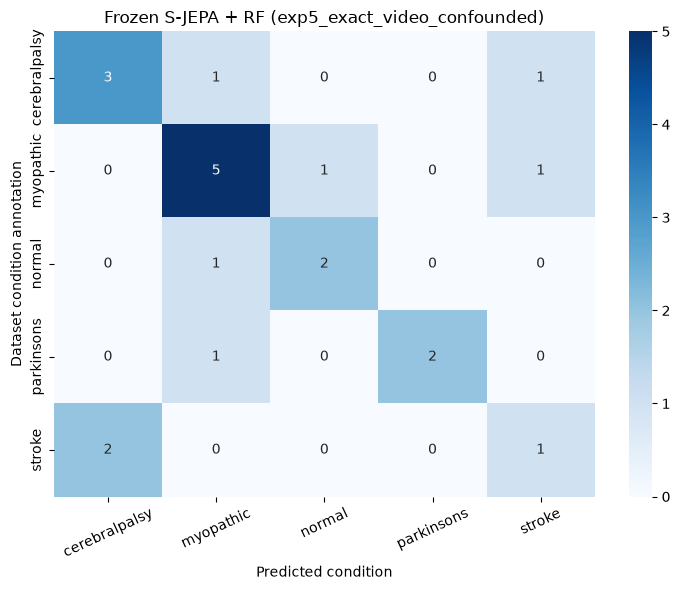

,sequence_id,video_id,true_condition,predicted_condition
0,cljo84jju00553n6lmgm4dqtb,05oyBOE_0UE,myopathic,stroke
1,cljo33m8400263n6l4xxsl6ku,3KnFt8bH3tE,normal,myopathic
5,cljo8eumx00683n6le2s7myd4,5gpoegYv1hs,stroke,cerebralpalsy
6,cljas5esv00fn3n6lewd5xqdl,DlPDuHBAP7A,cerebralpalsy,myopathic
7,cljnz4y5a000k3n6lkv4b1rjn,_Wn9oYGpRdM,parkinsons,myopathic
10,cljarn9oy00dl3n6l8pg9exfg,R8LRCiTvUz8,myopathic,normal
12,cljo8e32t00643n6l37ncjeic,5gpoegYv1hs,stroke,cerebralpalsy
15,cljas134500f73n6lkfbjfayp,DlPDuHBAP7A,cerebralpalsy,stroke


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

five_class_confusion = confusion_matrix(
    labels[test_index],
    five_class_prediction,
    labels=CLASS_ORDER,
)
confusion_figure, confusion_axis = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    five_class_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=confusion_axis,
)
confusion_axis.set_title(f"Frozen S-JEPA + RF ({split_name})")
confusion_axis.set_xlabel("Predicted condition")
confusion_axis.set_ylabel("Dataset condition annotation")
confusion_axis.tick_params(axis="x", labelrotation=25)
confusion_figure.tight_layout()
confusion_figure.savefig(
    ARTIFACT_DIR / "five_class_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
error_table = pd.DataFrame({
    "sequence_id": sequence_ids[test_index],
    "video_id": video_ids[test_index],
    "true_condition": labels[test_index],
    "predicted_condition": five_class_prediction,
})
error_table = error_table[
    error_table["true_condition"] != error_table["predicted_condition"]
]
display(error_table)


## Four one-versus-normal classifiers

Each binary model uses the same all-sequence train and test IDs as Lane A1. The class filter is applied only after the global split. This uses all available condition-folder rows without selecting an easier split for one condition.


In [19]:
binary_rows = []
binary_models = {}
for condition in [c for c in CONDITIONS if c != "normal"]:
    train_keep = np.isin(
        labels[all_train_index], ["normal", condition]
    )
    test_keep = np.isin(
        labels[all_test_index], ["normal", condition]
    )
    binary_train = all_train_index[train_keep]
    binary_test = all_test_index[test_keep]
    classifier = make_rf()
    classifier.fit(
        embeddings[binary_train],
        labels[binary_train],
    )
    prediction = classifier.predict(embeddings[binary_test])
    metrics = score_predictions(labels[binary_test], prediction)
    probabilities = classifier.predict_proba(embeddings[binary_test])
    class_names = classifier.named_steps["rf"].classes_.tolist()
    auc = float("nan")
    if set(labels[binary_test]) == {"normal", condition}:
        condition_column = class_names.index(condition)
        y_binary = (labels[binary_test] == condition).astype(int)
        auc = roc_auc_score(
            y_binary, probabilities[:, condition_column]
        )
    binary_rows.append({
        "task": "one_vs_normal",
        "condition_vs_normal": condition,
        "train_sequences": len(binary_train),
        "test_sequences": len(binary_test),
        **metrics,
        "roc_auc": auc,
        "mode": MODE,
        "split": all_split_name,
    })
    binary_models[condition] = classifier

binary_metrics = pd.DataFrame(binary_rows)
display(binary_metrics)


,task,condition_vs_normal,train_sequences,test_sequences,accuracy,balanced_accuracy,macro_f1,roc_auc,mode,split
0,one_vs_normal,parkinsons,14,7,0.714286,0.708333,0.708333,0.750000,real,all_96_stratified_video_confounded
1,one_vs_normal,stroke,17,7,0.857143,0.875000,0.857143,1.000000,real,all_96_stratified_video_confounded
2,one_vs_normal,cerebralpalsy,19,9,0.888889,0.875000,0.883117,1.000000,real,all_96_stratified_video_confounded
3,one_vs_normal,myopathic,41,18,0.777778,0.678571,0.678571,0.910714,real,all_96_stratified_video_confounded


## Lane B: video-disjoint scientific evaluation

The minimum requirement is two independent source videos in every class. With only one normal source video, a grouped fold would either put every normal sample in training or remove the normal class from training. Neither is a valid five-class test.

There is a second requirement. The target encoder must be pretrained again inside each outer training fold. Grouping only the Random Forest while reusing an encoder that saw held-out normal videos would still leak representation-learning information.


In [20]:
video_census = (
    pd.DataFrame({"condition": labels, "video_id": video_ids})
    .groupby("condition")["video_id"]
    .nunique()
    .reindex(CONDITIONS)
)
display(video_census.rename("unique_videos").to_frame())

grouped_metrics = None
if int(video_census.min()) < 2:
    print(
        "BLOCKED: five-class video-disjoint evaluation needs at least "
        "two source videos in every class."
    )
else:
    print(
        "NOT RUN: pretrain a fresh S-JEPA target encoder inside each "
        "outer video-group fold before fitting its Random Forest."
    )


,unique_videos
condition,
normal,1
parkinsons,2
stroke,3
cerebralpalsy,2
myopathic,10


BLOCKED: five-class video-disjoint evaluation needs at least two source videos in every class.


## Compare with the checked exp5 result

The exp5 confusion matrix below was recovered from its saved notebook output. Rows and columns are cerebralpalsy, myopathic, normal, parkinsons, stroke.

\[
\begin{bmatrix}
3&1&0&1&0\\\\
0&7&0&0&0\\\\
0&0&3&0&0\\\\
1&0&0&2&0\\\\
1&1&0&0&1
\end{bmatrix}
\]


In [21]:
comparison = pd.DataFrame([
    {
        "system": "exp5 handcrafted 82-feature RF",
        "mode": "real saved result",
        "split": "exact 47/21, video-confounded",
        "accuracy": 0.7619047619047619,
        "macro_f1": 0.7283333333333333,
        "independent_video_test": False,
    },
    {
        "system": "frozen S-JEPA pooled latent RF",
        "mode": MODE,
        "split": split_name,
        "accuracy": five_class_metrics["accuracy"],
        "macro_f1": five_class_metrics["macro_f1"],
        "independent_video_test": False,
    },
    {
        "system": "frozen S-JEPA pooled latent RF, all rows",
        "mode": MODE,
        "split": all_split_name,
        "accuracy": all_sequence_metrics["accuracy"],
        "macro_f1": all_sequence_metrics["macro_f1"],
        "independent_video_test": False,
    },
])
display(comparison)
if MODE == "smoke":
    print(
        "The S-JEPA row is a synthetic code-path check and is not "
        "comparable with the real exp5 result."
    )


,system,mode,split,accuracy,macro_f1,independent_video_test
0,exp5 handcrafted 82-feature RF,real saved result,"exact 47/21, video-confounded",0.761905,0.728333,False
1,frozen S-JEPA pooled latent RF,real,exp5_exact_video_confounded,0.619048,0.613333,False
2,"frozen S-JEPA pooled latent RF, all rows",real,all_96_stratified_video_confounded,0.620690,0.593651,False


## Why the exp5 number is only a reference point

Local methodology review found:

- Every one of its 21 test sequences shares a source video with training.
- The split is not stratified or group-aware.
- Pose extraction ignores the GAVD bbox.
- FPS is hardcoded to 30 although source videos include other rates.
- Twenty-two stored features are all zero and FPS is another constant feature.
- Legacy temporal ankle logic uses COCO indices 15 and 16, which are wrists in BlazePose. Correct BlazePose ankle indices are 27 and 28.

These findings do not erase the baseline. They define what a fair comparison can and cannot claim.

This is a system-level comparison, not an isolated representation ablation. The S-JEPA lane uses bbox-aware MediaPipe poses while exp5 used a different extraction and handcrafted-feature pipeline. A score difference cannot be attributed to S-JEPA alone. A causal representation comparison would compute both feature sets from the same cached poses and use the same split.


## Save models and metrics

Results remain namespaced by smoke or real mode.


In [22]:
import hashlib
import joblib
import json

metric_rows = [
    {
        "task": "five_class_exp5_exact",
        "condition": "all",
        "mode": MODE,
        "split": split_name,
        **five_class_metrics,
    },
    {
        "task": "five_class_all_sequences",
        "condition": "all",
        "mode": MODE,
        "split": all_split_name,
        **all_sequence_metrics,
    },
]
metric_rows.extend(
    binary_metrics.rename(
        columns={"condition_vs_normal": "condition"}
    ).to_dict("records")
)
metrics_table = pd.DataFrame(metric_rows)
metrics_table.to_csv(
    ARTIFACT_DIR / "classifier_metrics.csv",
    index=False,
)
leakage_audit.to_csv(
    ARTIFACT_DIR / "leakage_audit.csv",
    index=False,
)
comparison.to_csv(
    ARTIFACT_DIR / "exp5_comparison.csv",
    index=False,
)
five_class_report.to_csv(
    ARTIFACT_DIR / "five_class_classification_report.csv"
)
all_sequence_report.to_csv(
    ARTIFACT_DIR / "all_sequences_classification_report.csv"
)
error_table.to_csv(
    ARTIFACT_DIR / "five_class_errors.csv", index=False
)
all_error_table.to_csv(
    ARTIFACT_DIR / "all_sequences_errors.csv", index=False
)
pd.DataFrame(
    five_class_confusion,
    index=CLASS_ORDER,
    columns=CLASS_ORDER,
).to_csv(ARTIFACT_DIR / "five_class_confusion_matrix.csv")
pd.DataFrame(
    all_sequence_confusion,
    index=CLASS_ORDER,
    columns=CLASS_ORDER,
).to_csv(ARTIFACT_DIR / "all_sequences_confusion_matrix.csv")
missingness_audit = pd.DataFrame([
    {
        "lane": "all_sequences",
        "split": all_split_name,
        **all_missingness_metrics,
    },
    {
        "lane": "exp5_exact",
        "split": split_name,
        **exp5_missingness_metrics,
    },
])
missingness_audit.to_csv(
    ARTIFACT_DIR / "missingness_only_classifier_metrics.csv",
    index=False,
)
embedding_hasher = hashlib.sha256()
for sequence_id, embedding in sorted(
    zip(sequence_ids, embeddings), key=lambda item: item[0]
):
    embedding_hasher.update(str(sequence_id).encode("utf-8"))
    embedding_hasher.update(
        np.ascontiguousarray(embedding).tobytes()
    )
binary_row_contract = {}
for condition in [c for c in CONDITIONS if c != "normal"]:
    binary_row_contract[condition] = {
        "train_sequence_ids": sequence_ids[
            all_train_index[
                np.isin(
                    labels[all_train_index], ["normal", condition]
                )
            ]
        ].tolist(),
        "test_sequence_ids": sequence_ids[
            all_test_index[
                np.isin(
                    labels[all_test_index], ["normal", condition]
                )
            ]
        ].tolist(),
    }
model_contract = {
    "mode": MODE,
    "splits": {
        "all_sequences": all_split_name,
        "exp5_exact": split_name,
    },
    "checkpoint_fingerprint": checkpoint["dataset_fingerprint"],
    "embedding_corpus_sha256": embedding_hasher.hexdigest(),
    "mask_keypoints": MASK_KEYPOINTS,
    "feature_count": len(feature_columns),
    "class_order": CLASS_ORDER,
    "exp5_exact_train_sequence_ids": list(train_ids),
    "exp5_exact_test_sequence_ids": list(test_ids),
    "all_sequences_train_sequence_ids": all_train_ids,
    "all_sequences_test_sequence_ids": all_test_ids,
    "binary_row_contract": binary_row_contract,
}
(ARTIFACT_DIR / "classifier_contract.json").write_text(
    json.dumps(model_contract, indent=2) + "\n",
    encoding="utf-8",
)
joblib.dump(
    five_class_model,
    ARTIFACT_DIR / "five_class_exp5_exact_random_forest.joblib",
)
joblib.dump(
    all_sequence_model,
    ARTIFACT_DIR / "five_class_all_sequences_random_forest.joblib",
)
joblib.dump(
    all_missingness_model,
    ARTIFACT_DIR / "all_sequences_missingness_audit.joblib",
)
joblib.dump(
    exp5_missingness_model,
    ARTIFACT_DIR / "exp5_exact_missingness_audit.joblib",
)
for condition, classifier in binary_models.items():
    joblib.dump(
        classifier,
        ARTIFACT_DIR / f"{condition}_vs_normal_random_forest.joblib",
    )
print("saved capstone artifacts under", ARTIFACT_DIR)


saved capstone artifacts under /Users/pmui/dev/alexpose/penny/gavd3/cache/artifacts/real


## Capstone conclusion template

Report:

1. S-JEPA checkpoint fingerprint and pretraining mode.
2. Number of sequences and independent source videos per condition.
3. Exact split and train-test video overlap.
4. Five-class accuracy, balanced accuracy, macro-F1, and confusion matrix.
5. Separate all-96 exploratory results from the exact 68-row exp5 comparison.
6. Four binary metrics with test counts.
7. Missingness-only audit metrics and pose-coverage differences by condition.
8. Whether test normal sequences were present during self-supervised pretraining.
9. A statement that folder labels are dataset annotations and the result is exploratory and non-diagnostic.

Do not write that S-JEPA generalizes to unseen patients or videos until the data contains independent normal videos and subject-disjoint evaluation becomes possible.
